# TechMind — Análisis exploratorio y preparación del dataset

Corpus técnico bilingüe construido por el equipo, con el que se entrena el
clasificador de contenido de TechMind AI.

**El orden de este notebook no es casual.** Primero se explora el dataset crudo,
porque cada decisión de limpieza tiene que justificarse con algo observado en los
datos y no con una receta genérica. Después se limpia. Y al final se vuelve a
explorar, para comprobar que la limpieza hizo lo que debía y no rompió nada por
el camino.

| Parte | Qué responde |
|---|---|
| 1 · Exploración inicial | ¿Qué tenemos y qué hay que arreglar? |
| 2 · Limpieza | Arreglar exactamente eso, y nada más |
| 3 · Verificación | ¿La limpieza funcionó? ¿Se perdió algo? |
| 4 · Preparación | Dejarlo listo para entrenar sin fuga de datos |


In [1]:
import re
import json
from datetime import date
from pathlib import Path


def localizar(nombre, *carpetas):
    """Busca `nombre` en las carpetas dadas y devuelve la primera que exista.

    El notebook corre desde dos disposiciones: dentro del repositorio, donde
    los archivos quedan repartidos entre eda/ y machine_learning/, y desde una
    carpeta de entrega donde estan todos juntos. Probar las dos evita tener
    que editar rutas a mano cada vez que algo se mueve.
    """
    for carpeta in carpetas:
        ruta = Path(carpeta) / nombre
        if ruta.exists():
            return ruta
    buscado = ", ".join(str(Path(c).resolve()) for c in carpetas)
    raise FileNotFoundError(f"No se encontro {nombre}. Se busco en: {buscado}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)

## Carga

El archivo vive en el repositorio en `dataset/processed/techmind_dataset_v2.csv`.
Se comprueba al cargarlo que llegue completo: si el conteo de filas no coincide
con lo esperado, todos los números que siguen serían distintos y el notebook
estaría documentando un dataset que no es el publicado.

In [2]:
RUTA = localizar("techmind_dataset_v2.csv", ".", "../dataset/processed", "../dataset", "..")
FILAS_ESPERADAS = 38276

df = pd.read_csv(RUTA)

print(f"Archivo cargado: {RUTA}")
print(f"Filas: {len(df):,}   Columnas: {df.shape[1]}")

if len(df) != FILAS_ESPERADAS:
    print(f"\nATENCION: se esperaban {FILAS_ESPERADAS:,} filas y llegaron {len(df):,}.")
    print("Puede tratarse de otra copia del CSV. Los conteos de este notebook")
    print("no coincidirian con el dataset publicado en el repositorio.")
else:
    print("Integridad verificada: coincide con el dataset del repositorio.")

df.head(3)

Archivo cargado: ..\dataset\processed\techmind_dataset_v2.csv
Filas: 38,276   Columnas: 6
Integridad verificada: coincide con el dataset del repositorio.


,titulo,texto,categoria,palabras_clave,fuente,idioma
0,How to convert RGB matrix to binary array in MATLAB,I wrote a code to convert image(jpg) to binary using Matlab for bidirectional visible ...,Ciencia de Datos,matlab,stackoverflow,en
1,"Why is this ""call is ambiguous between the following methods or properties"" when calli...","Error CS0121 : The call is ambiguous between the following methods or properties: ""Mic...",DevOps / Cloud,"c#, azure, dependency-injection",stackoverflow,en
2,Our failure story with Redis operator for K8s (+ a brief look at Redis data analysis t...,What will happen if you use a well-known and established in-memory key-value store as ...,DevOps / Cloud,"['DevOps', 'Kubernetes Operator', 'Kubernetes', 'fix', 'Redis']",medium,en


### Qué contiene cada columna

In [3]:
descripcion = {
    "titulo":         "Titulo del contenido tecnico",
    "texto":          "Cuerpo del documento — es lo que el modelo clasifica",
    "categoria":      "Etiqueta objetivo, una de las 8 categorias",
    "palabras_clave": "Terminos asociados al contenido",
    "fuente":         "De donde se obtuvo el registro",
    "idioma":         "es / en",
}
pd.DataFrame({
    "columna": df.columns,
    "tipo": [str(df[col].dtype) for col in df.columns],
    "nulos": [int(df[col].isna().sum()) for col in df.columns],
    "descripcion": [descripcion.get(col, "") for col in df.columns],
})

,columna,tipo,nulos,descripcion
0,titulo,object,0,Titulo del contenido tecnico
1,texto,object,0,Cuerpo del documento — es lo que el modelo clasifica
2,categoria,object,0,"Etiqueta objetivo, una de las 8 categorias"
3,palabras_clave,object,524,Terminos asociados al contenido
4,fuente,object,0,De donde se obtuvo el registro
5,idioma,object,0,es / en


---

# Parte 1 · Exploración inicial

Antes de tocar nada. El objetivo es entender qué hay y detectar qué necesita
arreglo, para que cada paso de limpieza responda a un hallazgo concreto.

## 1.1 · Distribución de categorías

Lo primero que hay que saber de un dataset de clasificación: cuántas clases hay
y si están equilibradas. Con clases muy desiguales el modelo aprende bien las
grandes e ignora las chicas.

In [4]:
conteo = df["categoria"].value_counts()
ratio = conteo.max() / conteo.min()

resumen_cat = pd.DataFrame({
    "registros": conteo,
    "porcentaje": (conteo / len(df) * 100).round(2),
})
print(resumen_cat.to_string())
print(f"\nCategorias: {df['categoria'].nunique()}")
print(f"Mayoritaria: {conteo.idxmax()} ({conteo.max():,})")
print(f"Minoritaria: {conteo.idxmin()} ({conteo.min():,})")
print(f"Ratio max/min: {ratio:.2f}")
print("\nLectura: por debajo de 3 se considera manejable sin tecnicas de rebalanceo")
print("agresivas. Aun asi la clase minoritaria se vigila al evaluar el modelo.")

                      registros  porcentaje
categoria                                  
Frontend                   5398       14.10
Ciencia de Datos           5278       13.79
DevOps / Cloud             5242       13.70
Programación General       5185       13.55
Backend                    5088       13.29
Mobile                     5055       13.21
Bases de Datos             4237       11.07
Seguridad                  2793        7.30

Categorias: 8
Mayoritaria: Frontend (5,398)
Minoritaria: Seguridad (2,793)
Ratio max/min: 1.93

Lectura: por debajo de 3 se considera manejable sin tecnicas de rebalanceo
agresivas. Aun asi la clase minoritaria se vigila al evaluar el modelo.


## 1.2 · Valores faltantes

Un nulo en `texto` sería un registro inservible; uno en `palabras_clave` es
tolerable. Distinguirlos evita descartar filas que sí sirven.

In [5]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0]

if len(nulos) == 0:
    print("No hay valores nulos en ninguna columna.")
else:
    for col, n in nulos.items():
        criticidad = "CRITICO — la fila no sirve" if col in ("texto", "categoria") else "tolerable"
        print(f"{col:16s} {n:>6,} nulos ({n/len(df)*100:.2f}%)   {criticidad}")

palabras_clave      524 nulos (1.37%)   tolerable


## 1.3 · Duplicados

Es el control más importante de todos. Un texto repetido puede quedar a la vez
en entrenamiento y en evaluación, y entonces el modelo aprueba porque memorizó,
no porque entendió. Las métricas salen infladas y nadie se entera.

In [6]:
dup_texto = df.duplicated(subset=["texto"]).sum()
dup_total = df.duplicated().sum()

print(f"Filas identicas por completo : {dup_total:,}")
print(f"Textos repetidos             : {dup_texto:,}  ({dup_texto/len(df)*100:.2f}%)")

if dup_texto == 0:
    print("\nSin duplicados: no hay riesgo de que el modelo memorice un texto")
    print("visto en entrenamiento al evaluarlo.")

Filas identicas por completo : 0
Textos repetidos             : 0  (0.00%)

Sin duplicados: no hay riesgo de que el modelo memorice un texto
visto en entrenamiento al evaluarlo.


## 1.4 · Sesgos de origen e idioma

De dónde viene el corpus condiciona qué aprende el modelo. Si una categoría
saliera casi entera de una sola fuente, el modelo podría estar reconociendo el
estilo de esa fuente en lugar del tema.

In [7]:
por_fuente = df["fuente"].value_counts()
por_idioma = df["idioma"].value_counts()

print("POR FUENTE")
for f, n in por_fuente.items():
    print(f"  {f:18s} {n:>7,}  ({n/len(df)*100:5.1f}%)")

print("\nPOR IDIOMA")
for i, n in por_idioma.items():
    print(f"  {i:18s} {n:>7,}  ({n/len(df)*100:5.1f}%)")

print("\nConcentracion de la fuente principal por categoria:")
for cat in sorted(df["categoria"].unique()):
    sub = df[df["categoria"] == cat]
    top = sub["fuente"].value_counts()
    print(f"  {cat:22s} {top.index[0]:14s} {top.iloc[0]/len(sub)*100:5.1f}%   ({sub['fuente'].nunique()} fuentes)")

POR FUENTE
  stackoverflow       25,574  ( 66.8%)
  medium              11,140  ( 29.1%)
  freecodecamp_es        659  (  1.7%)
  wikipedia_es           379  (  1.0%)
  corpus_es_ocr          286  (  0.7%)
  corpus_es_pdf          238  (  0.6%)

POR IDIOMA
  en                  36,714  ( 95.9%)
  es                   1,562  (  4.1%)

Concentracion de la fuente principal por categoria:
  Backend                stackoverflow   68.8%   (4 fuentes)
  Bases de Datos         stackoverflow   82.6%   (5 fuentes)
  Ciencia de Datos       stackoverflow   66.3%   (5 fuentes)
  DevOps / Cloud         stackoverflow   66.8%   (5 fuentes)
  Frontend               stackoverflow   64.8%   (4 fuentes)
  Mobile                 stackoverflow   69.2%   (4 fuentes)
  Programación General   stackoverflow   67.5%   (6 fuentes)
  Seguridad              medium          53.7%   (5 fuentes)


**Lo que hay que decir de esto, y no esconder:** el corpus es mayoritariamente
en inglés y proviene sobre todo de preguntas de foro. Son dos sesgos reales y
conocidos.

No son bloqueantes porque el vocabulario técnico —`docker`, `python`, `api`,
`jwt`— se escribe igual en ambos idiomas, y es justamente donde el modelo se
apoya para decidir. El corpus en español se incorporó para reforzar ese caso.

Ninguna categoría depende de una sola fuente, que era el riesgo grave: eso
llevaría al modelo a reconocer el estilo del origen en lugar del tema.

## 1.5 · Longitud de los documentos

Determina qué ve el modelo. Textos demasiado cortos no tienen señal suficiente;
los desmesurados pesan de más frente a un documento normal.

In [8]:
df["n_palabras"] = df["texto"].astype(str).str.split().str.len()
desc = df["n_palabras"].describe()

print(f"Minimo   : {desc['min']:>8,.0f} palabras")
print(f"Percentil 25: {desc['25%']:>5,.0f}")
print(f"Mediana  : {desc['50%']:>8,.0f}")
print(f"Percentil 75: {desc['75%']:>5,.0f}")
print(f"Percentil 95: {df['n_palabras'].quantile(.95):>5,.0f}")
print(f"Percentil 99: {df['n_palabras'].quantile(.99):>5,.0f}")
print(f"Maximo   : {desc['max']:>8,.0f}")

cortos = (df["n_palabras"] < 20).sum()
p99 = df["n_palabras"].quantile(.99)
largos = (df["n_palabras"] > p99).sum()

print(f"\nTextos de menos de 20 palabras : {cortos:,}  -> se descartan (sin senal suficiente)")
print(f"Textos por encima del p99      : {largos:,}  -> se conservan enteros")
print("\nSobre los extremos: se conservan porque aportan la categoria correcta y")
print("vocabulario valido. Si en el entrenamiento se detectara que distorsionan,")
print("la alternativa es truncarlos al p99, nunca descartarlos.")

Minimo   :       14 palabras
Percentil 25:    84
Mediana  :      145
Percentil 75:   368
Percentil 95: 1,474
Percentil 99: 2,648
Maximo   :   33,335

Textos de menos de 20 palabras : 2  -> se descartan (sin senal suficiente)
Textos por encima del p99      : 383  -> se conservan enteros

Sobre los extremos: se conservan porque aportan la categoria correcta y
vocabulario valido. Si en el entrenamiento se detectara que distorsionan,
la alternativa es truncarlos al p99, nunca descartarlos.


## 1.6 · Panorama visual

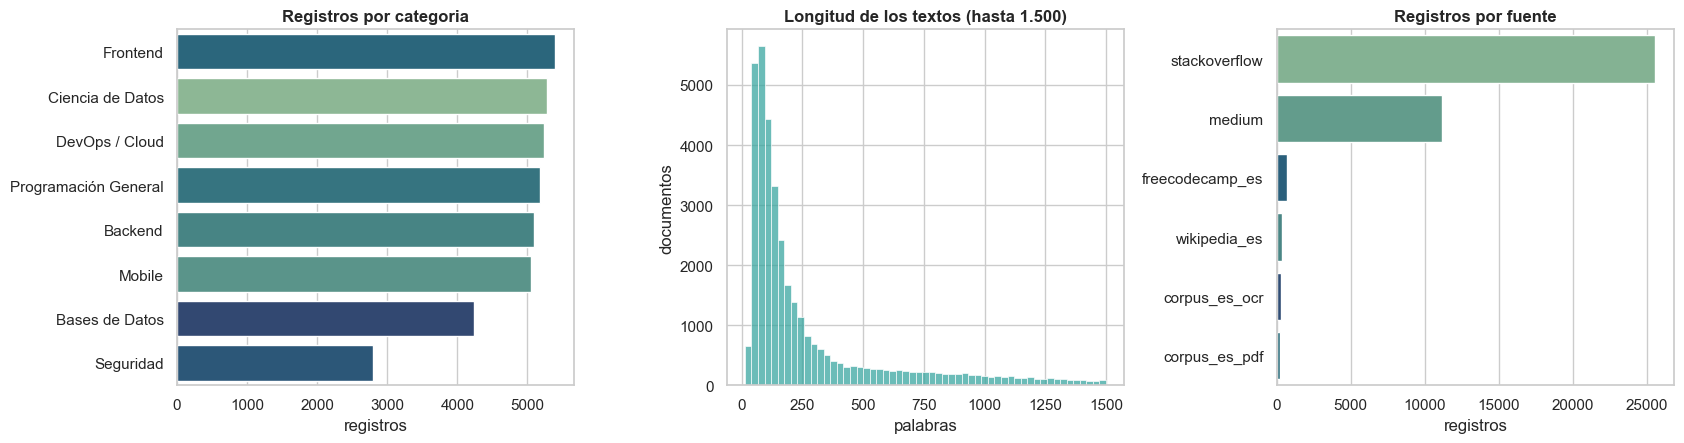

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

orden = df["categoria"].value_counts().index
sns.countplot(data=df, y="categoria", order=orden, ax=axes[0],
              hue="categoria", legend=False, palette="crest")
axes[0].set_title("Registros por categoria", fontweight="bold")
axes[0].set_xlabel("registros"); axes[0].set_ylabel("")

sns.histplot(df[df["n_palabras"] < 1500]["n_palabras"], bins=55,
             ax=axes[1], color="#3aa6a0")
axes[1].set_title("Longitud de los textos (hasta 1.500)", fontweight="bold")
axes[1].set_xlabel("palabras"); axes[1].set_ylabel("documentos")

sns.countplot(data=df, y="fuente", order=df["fuente"].value_counts().index,
              ax=axes[2], hue="fuente", legend=False, palette="crest")
axes[2].set_title("Registros por fuente", fontweight="bold")
axes[2].set_xlabel("registros"); axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig("eda_panorama_inicial.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.7 · Conclusiones de la exploración

Esto es lo que se encontró, y es lo que la Parte 2 va a arreglar. Cada línea de
limpieza responde a un punto de esta lista.

In [10]:
hallazgos = [
    ("Categorias",  f"{df['categoria'].nunique()} clases, ratio {ratio:.2f}",
     "Equilibrado. Conservar las 8 sin agrupar."),
    ("Nulos",       f"{int(df['palabras_clave'].isna().sum()):,} en palabras_clave",
     "Rellenar con marcador. No eliminar la fila: el texto sirve."),
    ("Duplicados",  f"{dup_texto:,} textos repetidos",
     "Sin riesgo de fuga por esta via."),
    ("Idioma",      f"{por_idioma.iloc[0]/len(df)*100:.1f}% {por_idioma.index[0]}",
     "Apoyarse en vocabulario tecnico, comun a ambos idiomas."),
    ("Fuente",      f"{por_fuente.iloc[0]/len(df)*100:.1f}% {por_fuente.index[0]}",
     "Ninguna categoria depende de una sola fuente."),
    ("Textos cortos", f"{cortos:,} con menos de 20 palabras",
     "Descartar: no aportan senal."),
    ("Textos largos", f"maximo {desc['max']:,.0f} palabras",
     "Conservar enteros; truncar al p99 solo si distorsionan."),
]
print(f"{'ASPECTO':15s} {'OBSERVADO':34s} DECISION")
print("-" * 108)
for a, o, d in hallazgos:
    print(f"{a:15s} {o:34s} {d}")

ASPECTO         OBSERVADO                          DECISION
------------------------------------------------------------------------------------------------------------
Categorias      8 clases, ratio 1.93               Equilibrado. Conservar las 8 sin agrupar.
Nulos           524 en palabras_clave              Rellenar con marcador. No eliminar la fila: el texto sirve.
Duplicados      0 textos repetidos                 Sin riesgo de fuga por esta via.
Idioma          95.9% en                           Apoyarse en vocabulario tecnico, comun a ambos idiomas.
Fuente          66.8% stackoverflow                Ninguna categoria depende de una sola fuente.
Textos cortos   2 con menos de 20 palabras         Descartar: no aportan senal.
Textos largos   maximo 33,335 palabras             Conservar enteros; truncar al p99 solo si distorsionan.


---

# Parte 2 · Limpieza

Cada paso responde a un hallazgo de la Parte 1. Se lleva la cuenta de cuántos
registros se pierden en cada uno, para que al final se pueda auditar de dónde
salió cada baja.

In [11]:
registros_iniciales = len(df)
bitacora = []

def anotar(paso, antes, despues, motivo):
    bitacora.append({
        "paso": paso, "antes": antes, "despues": despues,
        "eliminados": antes - despues, "motivo": motivo,
    })

print(f"Punto de partida: {registros_iniciales:,} registros")

Punto de partida: 38,276 registros


### 2.1 · Nulos en `palabras_clave`

Se rellenan en lugar de eliminar la fila. El texto y la categoría —que es lo que
el modelo necesita— están completos: descartar el registro por una columna
auxiliar sería tirar información útil.

In [12]:
antes = len(df)
n_nulos = int(df["palabras_clave"].isna().sum())
df["palabras_clave"] = df["palabras_clave"].fillna("sin_palabras_clave")
anotar("Nulos normalizados", antes, len(df), f"{n_nulos:,} rellenados, ninguna fila eliminada")
print(f"Rellenados: {n_nulos:,}   Registros: {len(df):,} (sin cambios)")

Rellenados: 524   Registros: 38,276 (sin cambios)


### 2.2 · Mapeo de categorías

Un diccionario explícito, no una búsqueda por coincidencia de texto. La razón es
concreta: buscar `"datos" in categoria` haría coincidir tanto *Ciencia de Datos*
como *Bases de Datos*, y las fundiría en una sola sin ningún aviso.

Los nombres se conservan exactamente como están porque son los mismos que
devuelve la API y muestra el frontend. Cambiar uno rompe la cadena.

In [13]:
MAPA_CATEGORIAS = {
    "Backend":              "Backend",
    "Frontend":             "Frontend",
    "Mobile":               "Mobile",
    "Ciencia de Datos":     "Ciencia de Datos",
    "Bases de Datos":       "Bases de Datos",
    "DevOps / Cloud":       "DevOps / Cloud",
    "Seguridad":            "Seguridad",
    "Programación General": "Programación General",
}

sin_mapear = set(df["categoria"].unique()) - set(MAPA_CATEGORIAS)
if sin_mapear:
    print(f"ATENCION: categorias fuera del mapa: {sin_mapear}")

antes = len(df)
df["categoria_final"] = df["categoria"].map(MAPA_CATEGORIAS)
df = df.dropna(subset=["categoria_final"])
anotar("Mapeo de categorias", antes, len(df), "sin coincidencia en el mapa")

print(f"Categorias antes : {len(MAPA_CATEGORIAS)}")
print(f"Categorias despues: {df['categoria_final'].nunique()}")
print("OK: las 8 se conservan." if df["categoria_final"].nunique() == 8
      else "ERROR: se perdio alguna categoria.")

Categorias antes : 8
Categorias despues: 8
OK: las 8 se conservan.


### 2.3 · Limpieza del texto

Se quitan URLs, encabezados de publicación y saltos de línea. **Se conservan los
caracteres `+ # . _ - /`**, y esa es la decisión que más pesa de toda la
limpieza: sin ellos `C++` y `C#` quedan vacíos, `CI/CD` desaparece y `node.js`
se reduce a `node`. Son justamente los términos que más distinguen una categoría
de otra.

Tampoco se pasa a minúsculas ni se borran dígitos: el vectorizador ya normaliza
las mayúsculas por su cuenta, y los dígitos forman parte de términos reales como
`HTML5` o `ES6`.

In [14]:
PATRON_PUBLICADO = re.compile(r"Published.*?:.*", flags=re.IGNORECASE)
PATRON_URL       = re.compile(r"http\S+|www\S+|https\S+", flags=re.MULTILINE)
PATRON_SALTOS    = re.compile(r"\n|\r")
PATRON_PERMITIDO = re.compile(r"[^áéíóúüñA-Za-z0-9\s\+\#\.\_\-\/]")
PATRON_ESPACIOS  = re.compile(r"\s+")

def limpiar_texto(texto):
    texto = str(texto)
    texto = PATRON_PUBLICADO.sub("", texto)
    texto = PATRON_URL.sub("", texto)
    texto = PATRON_SALTOS.sub(" ", texto)
    texto = PATRON_PERMITIDO.sub("", texto)
    return PATRON_ESPACIOS.sub(" ", texto).strip()

df["titulo_limpio"] = df["titulo"].apply(limpiar_texto)
df["texto_limpio"]  = df["texto"].apply(limpiar_texto)

print("Comprobacion sobre terminos tecnicos:")
for t in ["C++", "C#", "CI/CD", "TCP/IP", "node.js", "HTML5", ".NET", "front-end"]:
    r = limpiar_texto(t)
    print(f"  {t:12s} -> {r!r:14s} {'OK' if r == t else 'SE PERDIO'}")

Comprobacion sobre terminos tecnicos:
  C++          -> 'C++'          OK
  C#           -> 'C#'           OK
  CI/CD        -> 'CI/CD'        OK
  TCP/IP       -> 'TCP/IP'       OK
  node.js      -> 'node.js'      OK
  HTML5        -> 'HTML5'        OK
  .NET         -> '.NET'         OK
  front-end    -> 'front-end'    OK


### 2.4 · Normalización ortográfica

Colapsa caracteres repetidos (`looool` → `lool`) y corrige erratas frecuentes del
corpus. Es contenido escrito por personas en foros: estas variantes existen y
dispersan el vocabulario sin aportar significado.

In [15]:
CORRECCIONES = {
    r"\bteh\b": "the",           r"\brecieve\b": "receive",
    r"\bwich\b": "which",        r"\bwierd\b": "weird",
    r"\bthier\b": "their",       r"\baltough\b": "although",
    r"\bfuntion\b": "function",  r"\bfuncion\b": "función",
    r"\bcompatibilty\b": "compatibility",
}
CORRECCIONES_C = [(re.compile(p, re.IGNORECASE), r) for p, r in CORRECCIONES.items()]
REPETIDAS   = re.compile(r"(.)\1{2,}")
PUNTUACION  = re.compile(r"([!?.,])\1{1,}")

def corregir(texto):
    texto = REPETIDAS.sub(r"\1\1", str(texto))
    texto = PUNTUACION.sub(r"\1", texto)
    for patron, reemplazo in CORRECCIONES_C:
        texto = patron.sub(reemplazo, texto)
    return PATRON_ESPACIOS.sub(" ", texto).strip()

df["titulo_limpio"] = df["titulo_limpio"].apply(corregir)
df["texto_limpio"]  = df["texto_limpio"].apply(corregir)

for ejemplo in ["Esto es looool genial???", "teh error al recieve"]:
    print(f"  {ejemplo!r:32s} -> {corregir(ejemplo)!r}")

  'Esto es looool genial???'       -> 'Esto es lool genial?'
  'teh error al recieve'           -> 'the error al receive'


### 2.5 · Descarte de textos sin señal

Menos de 20 palabras no alcanza para identificar un tema técnico. Es el umbral
que salió de la Parte 1.

In [16]:
antes = len(df)
df["n_palabras"] = df["texto_limpio"].str.split().str.len()
df = df[df["n_palabras"] >= 20].copy()
anotar("Textos cortos", antes, len(df), "menos de 20 palabras")
print(f"Descartados: {antes - len(df):,}   Quedan: {len(df):,}")

Descartados: 19   Quedan: 38,257


### 2.6 · Duplicados tras limpiar

Se repite el control: dos textos distintos en crudo pueden quedar idénticos
después de quitarles URLs y puntuación.

In [17]:
antes = len(df)
df = df.drop_duplicates(subset=["texto_limpio"]).reset_index(drop=True)
anotar("Duplicados", antes, len(df), "texto identico tras limpiar")
print(f"Eliminados: {antes - len(df):,}   Quedan: {len(df):,}")

Eliminados: 0   Quedan: 38,257


### 2.7 · Auditoría de la limpieza

De dónde salió cada baja. Sin esta tabla, la diferencia entre el archivo de
entrada y el de salida es un número sin explicación.

In [18]:
auditoria = pd.DataFrame(bitacora)
print(auditoria.to_string(index=False))

perdidos = registros_iniciales - len(df)
print(f"\nEntraron : {registros_iniciales:,}")
print(f"Salieron : {len(df):,}")
print(f"Diferencia: {perdidos:,}  ({perdidos/registros_iniciales*100:.2f}%)")
assert df["categoria_final"].nunique() == 8, "Se perdio una categoria"
print("\nVerificado: las 8 categorias siguen presentes.")

               paso  antes  despues  eliminados                                 motivo
 Nulos normalizados  38276    38276           0 524 rellenados, ninguna fila eliminada
Mapeo de categorias  38276    38276           0            sin coincidencia en el mapa
      Textos cortos  38276    38257          19                   menos de 20 palabras
         Duplicados  38257    38257           0            texto identico tras limpiar

Entraron : 38,276
Salieron : 38,257
Diferencia: 19  (0.05%)



Verificado: las 8 categorias siguen presentes.


---

# Parte 3 · Verificación posterior

La limpieza terminó. Ahora hay que comprobar que hizo lo que debía: que no se
perdió ninguna categoría, que las proporciones se mantienen y que el texto
resultante conserva el vocabulario que el modelo necesita.

## 3.1 · Antes y después

In [19]:
comp = pd.DataFrame({
    "antes": df["categoria"].value_counts(),
    "despues": df["categoria_final"].value_counts(),
})
comp["diferencia"] = comp["despues"] - comp["antes"]
comp["% conservado"] = (comp["despues"] / comp["antes"] * 100).round(2)
print(comp.to_string())

faltantes = set(MAPA_CATEGORIAS.values()) - set(df["categoria_final"].unique())
print(f"\nCategorias perdidas: {faltantes if faltantes else 'ninguna'}")

idioma_despues = df["idioma"].value_counts(normalize=True) * 100
print("\nProporcion de idiomas (debe mantenerse):")
for i, p in idioma_despues.items():
    print(f"  {i}: {p:.1f}%")

                      antes  despues  diferencia  % conservado
Frontend               5396     5396           0         100.0
Ciencia de Datos       5277     5277           0         100.0
DevOps / Cloud         5239     5239           0         100.0
Programación General   5184     5184           0         100.0
Backend                5085     5085           0         100.0
Mobile                 5048     5048           0         100.0
Bases de Datos         4236     4236           0         100.0
Seguridad              2792     2792           0         100.0



Categorias perdidas: ninguna

Proporcion de idiomas (debe mantenerse):
  en: 95.9%
  es: 4.1%


## 3.2 · Términos característicos de cada categoría

El control más revelador de todos. Si el modelo va a poder distinguir las clases,
tiene que existir vocabulario propio de cada una.

**No sirve mirar los términos más frecuentes de cada categoría:** los primeros
puestos se los llevan `the`, `to`, `and` en todas por igual, porque son las
palabras más comunes del idioma y no distinguen nada.

Lo que se mide acá es la **distintividad**: cuánto pesa un término dentro de una
categoría comparado con su peso en el corpus entero. Un término que aparece en
todas partes queda con puntuación cercana a 1 y no sube; uno propio de una
categoría se dispara. Así emerge el vocabulario real sin depender de una lista
de palabras vacías, que además habría que mantener en dos idiomas.

In [20]:
vectorizador = TfidfVectorizer(max_features=8000, min_df=10, ngram_range=(1, 1))
matriz = vectorizador.fit_transform(df["texto_limpio"])
vocabulario = vectorizador.get_feature_names_out()

# Peso medio de cada termino en todo el corpus: la referencia contra la que se
# compara. El epsilon evita dividir por cero en terminos practicamente ausentes.
media_global = np.asarray(matriz.mean(axis=0)).ravel() + 1e-9

caracteristicas = {}
distintividad = {}
for cat in sorted(df["categoria_final"].unique()):
    idx = np.where(df["categoria_final"].values == cat)[0]
    media_cat = np.asarray(matriz[idx].mean(axis=0)).ravel()
    score = media_cat / media_global          # cuantas veces mas que el promedio
    score[media_cat < media_global.mean()] = 0  # descarta terminos casi ausentes
    top = score.argsort()[::-1][:8]
    caracteristicas[cat] = [vocabulario[i] for i in top]
    distintividad[cat] = [float(score[i]) for i in top]
    print(f"{cat:22s} {', '.join(caracteristicas[cat])}")

Backend                rspec, woocommerce, goroutine, artisan, hibernate, bean, rb, springframework
Bases de Datos         tidb, subquery, cte, pk, scylla, shard, clause, 2024
Ciencia de Datos       hyperparameters, ggplot, ggplot2, descent, convolution, pca, convolutional, plot
DevOps / Cloud         kube, terraform, helm, cloudformation, ansible, gke, dockerfile, cloudwatch
Frontend               divs, stackblitz, codepen, ssr, tailwind, flexbox, jsx, vite
Mobile                 recyclerview, swiftdata, appdelegate, uiview, storyboard, swiftui, jetpack, retrofit
Programación General   borrow, msvc, clang, lifetime, compilers, scrum, nums, crate
Seguridad              surfshark, burp, nordvpn, ransomware, phishing, cybersecurity, bounty, ataque


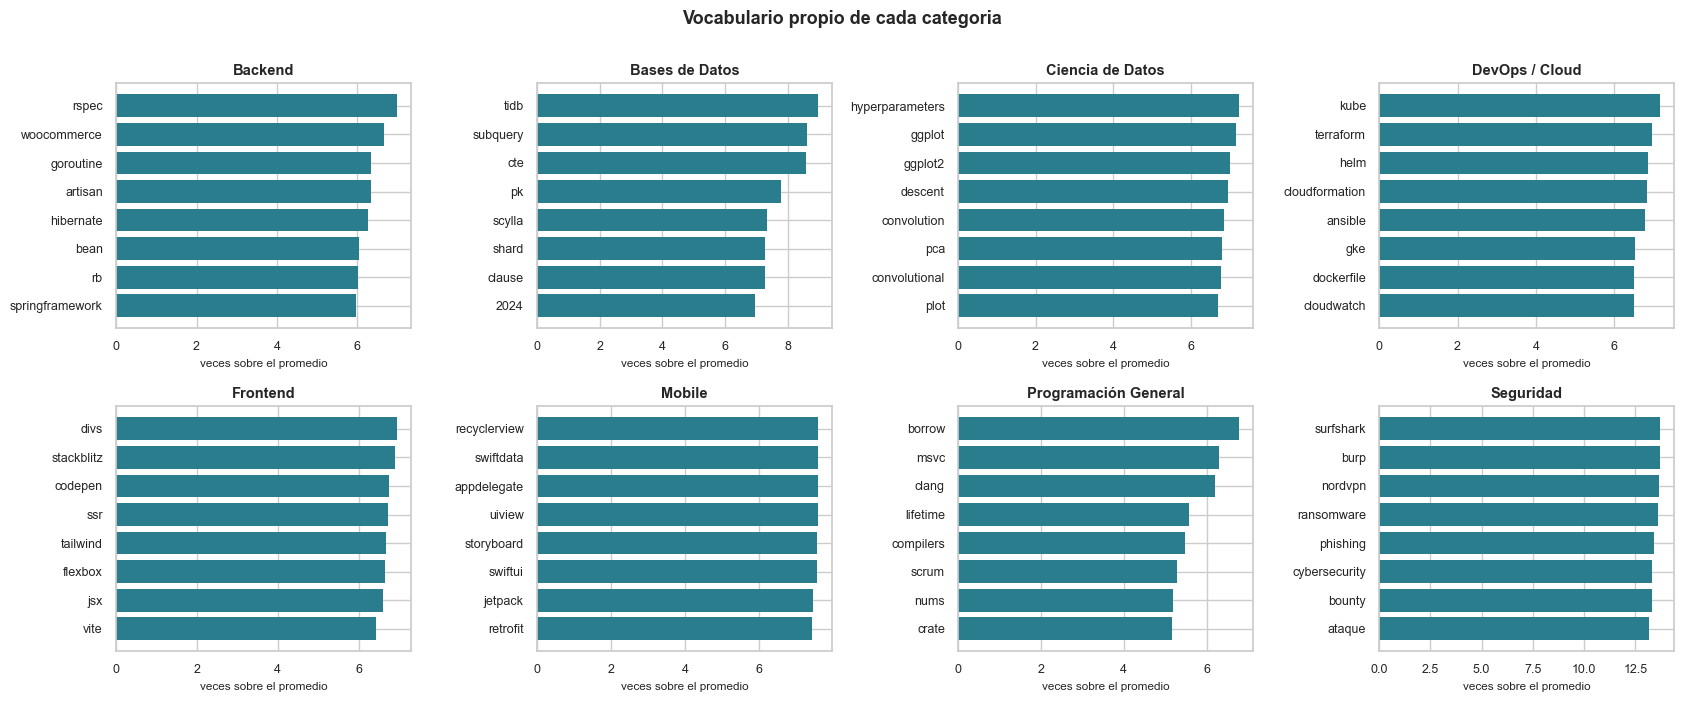

In [21]:
cats = list(caracteristicas)
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
colores = sns.color_palette("crest", 8)

for ax, cat in zip(axes.ravel(), cats):
    terminos = caracteristicas[cat][::-1]
    valores  = distintividad[cat][::-1]
    ax.barh(terminos, valores, color=colores[4], edgecolor="none")
    ax.set_title(cat, fontweight="bold", fontsize=10.5)
    ax.tick_params(labelsize=9)
    ax.set_xlabel("veces sobre el promedio", fontsize=8.5)

fig.suptitle("Vocabulario propio de cada categoria",
             fontweight="bold", fontsize=13, y=1.0)
plt.tight_layout()
plt.savefig("eda_vocabulario_por_categoria.png", dpi=150, bbox_inches="tight")
plt.show()

---

# Parte 4 · Preparación para el entrenamiento

Acá se decide si las métricas del modelo van a ser reales o mentira. **El orden
de estos dos pasos es lo único que importa:**

```
CORRECTO           dividir  →  balancear solo el entrenamiento
INCORRECTO         balancear  →  dividir
```

Balancear antes duplica registros de las clases chicas, y esos duplicados se
reparten después entre entrenamiento y prueba. El modelo termina evaluándose con
textos que ya vio: las métricas suben y no significan nada.

## 4.1 · División estratificada

`stratify` mantiene la proporción de cada categoría en ambos conjuntos. El de
prueba conserva la distribución real —desequilibrada— porque es la que el modelo
va a encontrar en producción.

In [22]:
X = df["titulo_limpio"].fillna("") + " " + df["texto_limpio"]
y = df["categoria_final"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Entrenamiento: {len(X_train):,}")
print(f"Prueba       : {len(X_test):,}")
print("\nDistribucion del conjunto de prueba (real, sin tocar):")
print(y_test.value_counts().to_string())

Entrenamiento: 30,605
Prueba       : 7,652

Distribucion del conjunto de prueba (real, sin tocar):
categoria_final
Frontend                1079
Ciencia de Datos        1056
DevOps / Cloud          1048
Programación General    1037
Backend                 1017
Mobile                  1010
Bases de Datos           847
Seguridad                558


> **Sobre `X`:** se concatena título y texto porque es exactamente lo que la API
> recibe en producción. Entrenar solo con el texto haría que el modelo aprenda
> una cosa y reciba otra.

## 4.2 · Balanceo, solo del entrenamiento

Sobremuestreo de las clases minoritarias hasta igualar la mayoritaria. Se elige
sobremuestrear y no submuestrear para no descartar información de las clases
grandes.

**El conjunto de prueba no se toca.**

In [23]:
train = pd.DataFrame({"texto": X_train, "categoria": y_train})
maximo = train["categoria"].value_counts().max()

partes = []
for cat, grupo in train.groupby("categoria"):
    if len(grupo) < maximo:
        extra = grupo.sample(n=maximo - len(grupo), replace=True, random_state=RANDOM_STATE)
        grupo = pd.concat([grupo, extra], ignore_index=True)
    partes.append(grupo)

train_bal = pd.concat(partes, ignore_index=True).sample(
    frac=1, random_state=RANDOM_STATE
).reset_index(drop=True)

print("ANTES de balancear")
print(train["categoria"].value_counts().to_string())
print(f"\nDESPUES ({len(train_bal):,} registros)")
print(train_bal["categoria"].value_counts().to_string())

ANTES de balancear
categoria
Frontend                4317
Ciencia de Datos        4221
DevOps / Cloud          4191
Programación General    4147
Backend                 4068
Mobile                  4038
Bases de Datos          3389
Seguridad               2234

DESPUES (34,536 registros)
categoria
Bases de Datos          4317
Mobile                  4317
Backend                 4317
Seguridad               4317
Programación General    4317
Frontend                4317
Ciencia de Datos        4317
DevOps / Cloud          4317


## 4.3 · Verificación de fuga

El control que cierra el notebook. Cuenta cuántos textos del conjunto de prueba
aparecen también en el de entrenamiento. **Tiene que dar cero.**

Si diera cualquier otro número, todas las métricas del modelo estarían infladas
y habría que volver a este punto antes de entrenar.

In [24]:
en_train = set(train_bal["texto"])
en_test   = set(X_test)
interseccion = en_train & en_test

print(f"Textos en entrenamiento : {len(en_train):,} unicos")
print(f"Textos en prueba        : {len(en_test):,} unicos")
print(f"Presentes en ambos      : {len(interseccion):,}")

if len(interseccion) == 0:
    print("\nSIN FUGA DE DATOS.")
    print("Cada texto de la evaluacion es nuevo para el modelo, asi que las")
    print("metricas van a reflejar capacidad real de generalizar.")
else:
    print(f"\nFUGA DETECTADA: {len(interseccion):,} textos repetidos.")
    print("No entrenar hasta corregirlo: las metricas saldrian infladas.")

Textos en entrenamiento : 30,605 unicos
Textos en prueba        : 7,652 unicos
Presentes en ambos      : 0

SIN FUGA DE DATOS.
Cada texto de la evaluacion es nuevo para el modelo, asi que las
metricas van a reflejar capacidad real de generalizar.


## 4.4 · Entregables

In [25]:
df_limpio = df[["titulo_limpio", "texto_limpio", "categoria_final",
                "palabras_clave", "fuente", "idioma"]]
df_limpio.to_csv("dataset_limpio.csv", index=False)
train_bal.to_csv("train_dataset.csv", index=False)
pd.DataFrame({"texto": X_test, "categoria": y_test}).to_csv("test_dataset.csv", index=False)

diccionario = {
    "generado": str(date.today()),
    "total_categorias": int(df["categoria_final"].nunique()),
    "categorias": {
        cat: {
            "registros": int((df["categoria_final"] == cat).sum()),
            "terminos_caracteristicos": caracteristicas[cat],
        }
        for cat in sorted(df["categoria_final"].unique())
    },
}
with open("diccionario_categorias.json", "w", encoding="utf-8") as f:
    json.dump(diccionario, f, ensure_ascii=False, indent=2)

for archivo in ["dataset_limpio.csv", "train_dataset.csv",
                "test_dataset.csv", "diccionario_categorias.json"]:
    print(f"  guardado: {archivo}")

  guardado: dataset_limpio.csv
  guardado: train_dataset.csv
  guardado: test_dataset.csv
  guardado: diccionario_categorias.json


---

# Parte 5 · Resumen

Qué quedó, qué se le hizo y por qué este dataset va a entrenar un buen modelo.
Cada número sale de una medición del notebook.

## 5.1 · El dataset y el proceso

In [26]:
ficha = pd.DataFrame([
    ("Registros finales", f"{len(df):,}   (de {registros_iniciales:,} iniciales)"),
    ("Categorias",        f"{df['categoria_final'].nunique()} clases tematicas"),
    ("Idiomas",           " · ".join(f"{i} {p:.1f}%" for i, p in
                          (df['idioma'].value_counts(normalize=True)*100).items())),
    ("Fuentes",           f"{df['fuente'].nunique()} distintas"),
    ("Longitud tipica",   f"mediana {df['n_palabras'].median():.0f} palabras"),
    ("Entrenamiento",     f"{len(train_bal):,} registros (balanceado)"),
    ("Prueba",            f"{len(X_test):,} registros (distribucion real)"),
], columns=["", "valor"])
print(ficha.to_string(index=False, header=False))

print("\nQUE SE LE HIZO")
for paso, decision in [
    ("Nulos",        "rellenados, no eliminados: el texto y la categoria estaban completos"),
    ("Categorias",   "mapeo explicito, para no fusionar 'Ciencia de Datos' con 'Bases de Datos'"),
    ("Texto",        "URLs fuera; + # . _ - / conservados, para no perder C++, C# ni CI/CD"),
    ("Textos cortos","descartados por debajo de 20 palabras"),
    ("Duplicados",   "verificados antes y despues de limpiar"),
]:
    print(f"  {paso:14s} {decision}")

Registros finales      38,257   (de 38,276 iniciales)
       Categorias                  8 clases tematicas
          Idiomas                  en 95.9% · es 4.1%
          Fuentes                         6 distintas
  Longitud tipica                mediana 144 palabras
    Entrenamiento       34,536 registros (balanceado)
           Prueba 7,652 registros (distribucion real)

QUE SE LE HIZO
  Nulos          rellenados, no eliminados: el texto y la categoria estaban completos
  Categorias     mapeo explicito, para no fusionar 'Ciencia de Datos' con 'Bases de Datos'
  Texto          URLs fuera; + # . _ - / conservados, para no perder C++, C# ni CI/CD
  Textos cortos  descartados por debajo de 20 palabras
  Duplicados     verificados antes y despues de limpiar


## 5.2 · Por qué va a funcionar

Seis condiciones. Un dataset que las cumple entrena bien; si falla alguna, el
problema aparece después y cuesta mucho más caro encontrarlo.

In [27]:
min_clase = int(df["categoria_final"].value_counts().min())
ratio_final = df["categoria_final"].value_counts().max() / min_clase
dup_final = int(df.duplicated(subset=["texto_limpio"]).sum())
fuentes_min = min(df[df["categoria_final"] == c]["fuente"].nunique()
                  for c in df["categoria_final"].unique())
distintividad_media = np.mean([np.mean(v) for v in distintividad.values()])

evidencias = [
    ("Volumen suficiente",
     f"{min_clase:,} registros en la clase mas chica",
     min_clase >= 1000,
     "Por debajo del millar una clase no alcanza a formar vocabulario propio"),

    ("Clases equilibradas",
     f"ratio {ratio_final:.2f} entre la mayor y la menor",
     ratio_final < 3,
     "Con clases muy desiguales el modelo aprende las grandes e ignora las chicas"),

    ("Sin duplicados",
     f"{dup_final} textos repetidos",
     dup_final == 0,
     "Un texto repetido permite memorizar en vez de aprender"),

    ("Sin fuga de datos",
     f"{len(interseccion)} textos compartidos entre train y test",
     len(interseccion) == 0,
     "Es lo que separa una metrica real de una inflada"),

    ("Vocabulario distintivo",
     f"{distintividad_media:.0f}x sobre el promedio del corpus",
     distintividad_media > 5,
     "Si las clases no tienen terminos propios, ningun modelo las separa"),

    ("Diversidad de origen",
     f"minimo {fuentes_min} fuentes por categoria",
     fuentes_min >= 2,
     "Una categoria de una sola fuente ensena a reconocer la fuente, no el tema"),
]

print(f"{'CONDICION':24s} {'MEDIDO':38s} {'':4s} POR QUE IMPORTA")
print("-" * 122)
for nombre, medido, cumple, motivo in evidencias:
    print(f"{nombre:24s} {medido:38s} {'OK ' if cumple else 'REV'}  {motivo}")

print("\n" + "=" * 122)
if all(e[2] for e in evidencias):
    print("Las seis condiciones se cumplen. El dataset esta en condiciones de entrenar")
    print("un clasificador cuyas metricas van a reflejar capacidad real de generalizar.")
else:
    print("Hay condiciones sin cumplir: revisarlas antes de entrenar.")

CONDICION                MEDIDO                                      POR QUE IMPORTA
--------------------------------------------------------------------------------------------------------------------------
Volumen suficiente       2,792 registros en la clase mas chica  OK   Por debajo del millar una clase no alcanza a formar vocabulario propio
Clases equilibradas      ratio 1.93 entre la mayor y la menor   OK   Con clases muy desiguales el modelo aprende las grandes e ignora las chicas
Sin duplicados           0 textos repetidos                     OK   Un texto repetido permite memorizar en vez de aprender
Sin fuga de datos        0 textos compartidos entre train y test OK   Es lo que separa una metrica real de una inflada
Vocabulario distintivo   8x sobre el promedio del corpus        OK   Si las clases no tienen terminos propios, ningun modelo las separa
Diversidad de origen     minimo 4 fuentes por categoria         OK   Una categoria de una sola fuente ensena a reconocer la fuen

De las seis, la que mejor predice el resultado es el **vocabulario distintivo**.
Las otras cinco son higiene: cualquier dataset limpio las cumple. Esta es la que
dice si el problema tiene solución.

Cada categoría tiene términos que prácticamente no aparecen en las demás
—`terraform` en DevOps, `subquery` en Bases de Datos, `recyclerview` en Mobile,
`ransomware` en Seguridad—. A un modelo lineal sobre TF-IDF le alcanza con
detectar esas señales, y por eso una técnica sencilla resuelve este problema sin
recurrir a arquitecturas más pesadas.

## 5.3 · Estado final

In [28]:
print("=" * 64)
print("DATASET LISTO PARA ENTRENAR")
print("=" * 64)
print(f"  Registros de entrada     : {registros_iniciales:,}")
print(f"  Despues de limpiar       : {len(df):,}   ({(len(df)/registros_iniciales)*100:.1f}% conservado)")
print(f"  Entrenamiento balanceado : {len(train_bal):,}")
print(f"  Prueba (sin tocar)       : {len(X_test):,}")
print(f"  Categorias               : {df['categoria_final'].nunique()}")
print(f"  Duplicados               : {dup_final}")
print(f"  Fuga de datos            : {len(interseccion)}")
print("=" * 64)
print()
print("SIGUIENTE PASO")
print("  Vectorizar con TF-IDF y entrenar el clasificador.")
print()
print("  Usar el test_dataset.csv generado aqui, SIN volver a dividir: esa")
print("  division es la que garantiza que no haya fuga. Si el notebook de")
print("  entrenamiento vuelve a partir los datos por su cuenta, se pierde")
print("  la garantia y las metricas dejan de ser confiables.")

DATASET LISTO PARA ENTRENAR
  Registros de entrada     : 38,276
  Despues de limpiar       : 38,257   (100.0% conservado)
  Entrenamiento balanceado : 34,536
  Prueba (sin tocar)       : 7,652
  Categorias               : 8
  Duplicados               : 0
  Fuga de datos            : 0

SIGUIENTE PASO
  Vectorizar con TF-IDF y entrenar el clasificador.

  Usar el test_dataset.csv generado aqui, SIN volver a dividir: esa
  division es la que garantiza que no haya fuga. Si el notebook de
  entrenamiento vuelve a partir los datos por su cuenta, se pierde
  la garantia y las metricas dejan de ser confiables.
